<a href="https://colab.research.google.com/github/zain4cs/Feature-Engineering/blob/main/Normalization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/wine_data.csv", header=None, usecols=[0,1,2])
df.columns = ['Class Label', 'Alcohol','Malic Acid']
df.head()

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

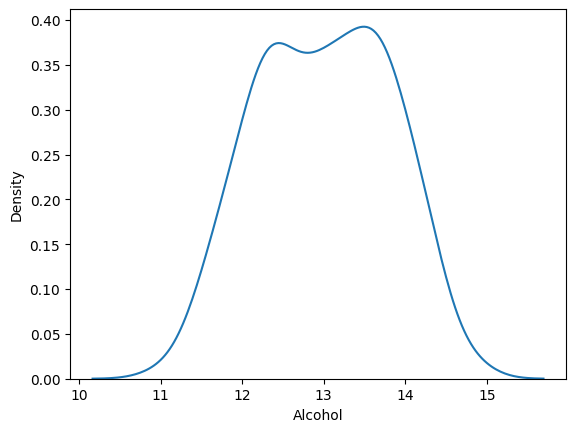

In [47]:
sns.kdeplot(df['Alcohol'])

<Axes: xlabel='Malic Acid', ylabel='Density'>

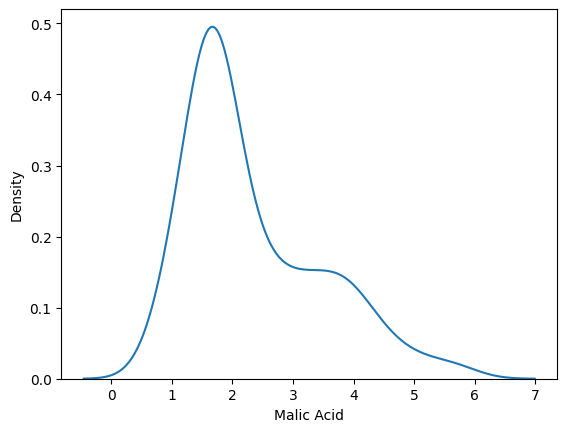

In [48]:
sns.kdeplot(df['Malic Acid'])

<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

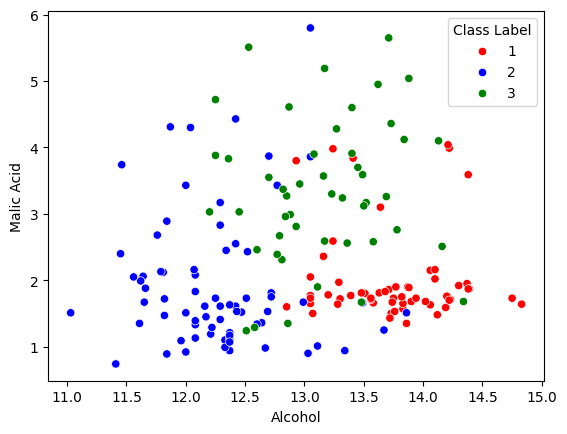

In [49]:
color_dict = {1: 'Red', 3:'Green',2: 'Blue'}
sns.scatterplot(data=df , x='Alcohol', y='Malic Acid', hue = 'Class Label', palette=color_dict)

_____________________________

In [50]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Class Label', axis=1),
                                                    df['Class Label'],
                                                    test_size=0.2,
                                                    random_state=42)

X_train.shape, X_test.shape

((142, 2), (36, 2))

_________________________

**Now Apply MinMax Scaler**

In [51]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaler = scaler.transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [52]:
X_train_scaler = pd.DataFrame(X_train_scaler, columns=X_train.columns)
X_test_scaler = pd.DataFrame(X_test_scaler, columns=X_train.columns)

In [53]:
X_test_scaler

,Alcohol,Malic Acid
0,0.686842,0.450102
1,0.836842,0.641548
2,0.500000,0.391039
3,0.710526,0.124236
4,0.352632,0.057026
5,0.860526,0.209776
6,0.255263,0.517312
7,0.623684,0.615071
8,0.152632,0.093686
9,0.613158,0.340122


<Axes: xlabel='Alcohol', ylabel='Malic Acid'>

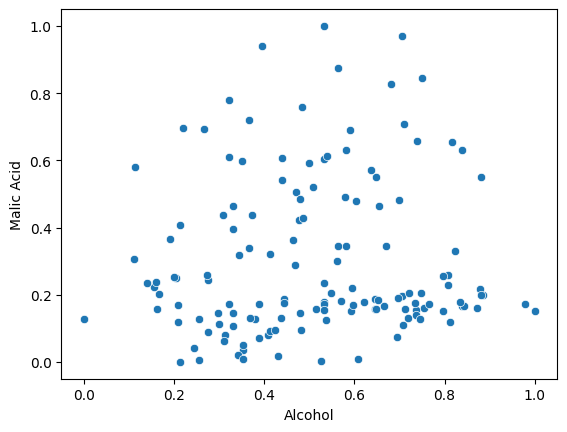

In [54]:
sns.scatterplot(data=X_train_scaler, x='Alcohol', y='Malic Acid')

In [55]:
np.round(X_train.describe(),1)

,Alcohol,Malic Acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.3,1.6
50%,13.0,1.9
75%,13.7,3.1
max,14.8,5.8


In [56]:
np.round(X_train_scaler.describe(),2)

,Alcohol,Malic Acid
count,142.00,142.00
mean,0.51,0.30
std,0.22,0.23
min,0.00,0.00
25%,0.34,0.15
50%,0.52,0.20
75%,0.70,0.46
max,1.00,1.00


_______________

**Graphs**

Text(0.5, 1.0, 'After Scaling')

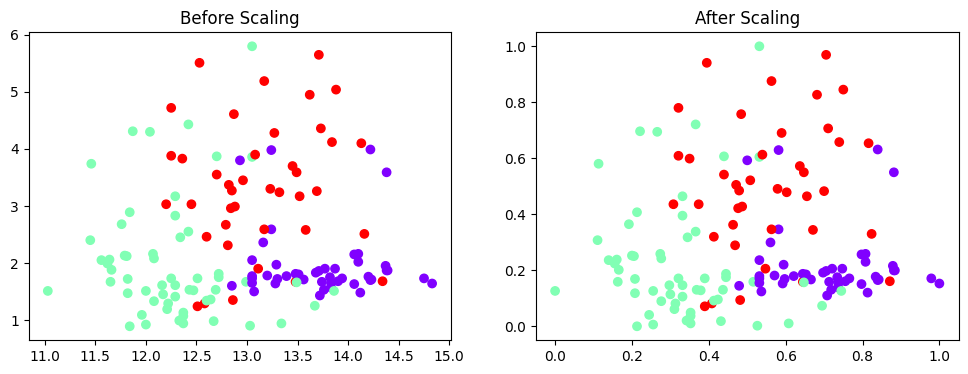

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,4))

ax1.scatter(X_train['Alcohol'], X_train['Malic Acid'], c=y_train, cmap='rainbow')
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaler['Alcohol'], X_train_scaler['Malic Acid'], c=y_train, cmap='rainbow')
ax2.set_title('After Scaling')